# Gast-Solla-Kennedy model: resting state on a full connectome

This demo simulates the **adaptive-Izhikevich mean-field model** of
Gast, Solla & Kennedy (2024, *PNAS* 121(22) e2311885121,
[doi:10.1073/pnas.2311885121](https://doi.org/10.1073/pnas.2311885121))
on a whole-brain structural connectome, in its **resting / quiescent regime**.

The model is a four-dimensional firing-rate reduction of a population of
all-to-all coupled adaptive (Izhikevich) neurons with a Lorentzian
distribution of spike thresholds. Its state variables are

| symbol | meaning |
|---|---|
| `r` | mean firing rate of the population (kHz) |
| `v` | mean membrane potential (mV) |
| `u` | mean recovery / spike-frequency-adaptation current (pA) |
| `s` | synaptic gating variable, driven by `r` |

The TVB implementation lives in `tvb.simulator.models.GastSollaKennedy`
(default parameters = regular-spiking RS column of Table 1 of the paper).
A companion notebook, `reproduce_figure_Gast_2024_PNAS.ipynb`, reproduces
the bifurcation / firing-rate panels of the paper at the single-population
level; this notebook instead places the model on the **76-region human
connectome** and looks at the low-activity resting state.

**Regime.** We start the population at its quiescent fixed point
(`r = 0`, `v = -60 mV`) and drive it with a small homogeneous external
current (`I = 30 pA`). This keeps the mean firing rate at, or extremely
close to, zero -- the population is *at rest* rather than tonically firing.
A short second run, started from a perturbed high-rate state, shows that
this resting state is a stable attractor.

In [1]:
from tvb.simulator.lab import *
import matplotlib.pyplot as plt
import numpy

## 1. Structural connectivity and model

We use the default 76-region structural connectome shipped with TVB
(weights + conduction delays). Note that this checkout requires an explicit
`connectivity.Connectivity.from_file()` (the `load_default=True` form is not
valid here) followed by `configure()`.

In [2]:
# Full 76-region human structural connectome (default weights and conduction delays)
conn = connectivity.Connectivity.from_file()
conn.configure()
print("Regions        :", conn.number_of_regions)
print("Max delay (mm) :", conn.tract_lengths.max())

# Adaptive-Izhikevich mean-field model (Gast, Solla & Kennedy 2024),
# regular-spiking (RS) parameter set (Table 1). A small external current of
# 30 pA places the population close to its quiescent (low-rate) fixed point.
model = models.GastSollaKennedy(I=numpy.array([30.0]))
print("Model          :", type(model).__name__)
print("State vars     :", model.state_variables)
print("Variables of interest (monitored):", model.variables_of_interest)

2026-09-23 13:58:18,977 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


Regions        : 76
Max delay (mm) : 153.48574
Model          : GastSollaKennedy
State vars     : ('r', 'v', 'u', 's')
Variables of interest (monitored): ('r',)


## 2. Helper: run the model on the full connectome

The longitudinal coupling is `coupling.Linear()` (the default), and the
model exposes its firing rate `r` to the coupling term. Integration is
deterministic (Heun, `dt = 0.01 ms`) and `r` is sampled every 1 ms.

In [3]:
def simulate(initial_rate, initial_v, initial_u, sim_length=1000.0):
    """Run the Gast-Solla-Kennedy mean field on the full connectome.

    The initial condition is homogeneous across regions and given by the
    per-region tuple ``(r, v, u, s)``: mean firing rate ``r`` (kHz),
    membrane potential ``v`` (mV), adaptation ``u`` (pA), gating ``s``.

    Returns the monitor time vector and the firing-rate array ``r(t)``
    with shape ``(time, regions)``.
    """
    x0 = numpy.array([initial_rate, initial_v, initial_u, 0.0])        # (r, v, u, s)
    ic = numpy.repeat(x0.reshape(4, 1, 1), conn.number_of_regions, axis=1)
    ic = ic.reshape((1, 4, conn.number_of_regions, 1))

    sim = simulator.Simulator(
        model=model,
        connectivity=conn,
        coupling=coupling.Linear(),
        integrator=integrators.HeunDeterministic(dt=0.01),
        monitors=(monitors.TemporalAverage(period=1.0),),
        initial_conditions=ic,
        simulation_length=sim_length,
    )
    sim.configure()

    (time, data), = sim.run()
    # data has shape (time, state_vars, regions, modes); state_vars = (r,)
    return time, data[:, 0, :, 0]

## 3. Resting-state simulation

Start every region at the quiescent fixed point: `r = 0`, `v = -60 mV`,
`u = 0`. With `I = 30 pA` the population stays at (or relaxes to) an
essentially zero firing-rate resting state.

In [4]:
time, r = simulate(initial_rate=0.0, initial_v=-60.0, initial_u=0.0, sim_length=1000.0)
print("monitored r(t) shape :", r.shape)
print("mean rate over all regions/time : %.3e kHz (%.3e Hz)" % (r.mean(), 1e3 * r.mean()))
print("max  rate over all regions/time : %.3e kHz (%.3e Hz)" % (r.max(), 1e3 * r.max()))

2026-09-23 13:58:19,071 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


monitored r(t) shape : (1000, 76)
mean rate over all regions/time : 2.513e-04 kHz (2.513e-01 Hz)
max  rate over all regions/time : 2.609e-04 kHz (2.609e-01 Hz)


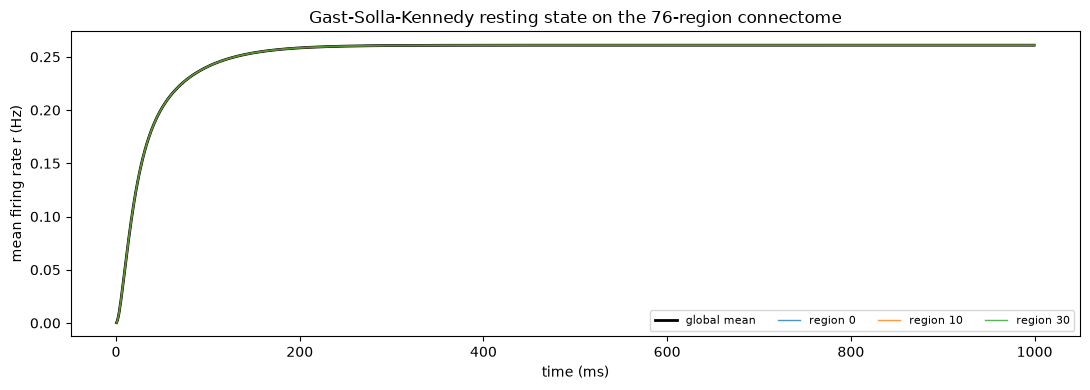

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(time, 1e3 * r.mean(axis=1), color="k", lw=2, label="global mean")
for i in (0, 10, 30):
    ax.plot(time, 1e3 * r[:, i], lw=1, alpha=0.8, label="region %d" % i)
ax.set_xlabel("time (ms)")
ax.set_ylabel("mean firing rate r (Hz)")
ax.set_title("Gast-Solla-Kennedy resting state on the 76-region connectome")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

The population sits at a near-zero firing rate: this is the resting /
quiescent state, not tonic firing.

## 4. Power spectrum of the resting-state activity

With the rate at a quiet fixed point the spectrum is essentially flat; this
is a useful sanity check that no spurious oscillation is present.

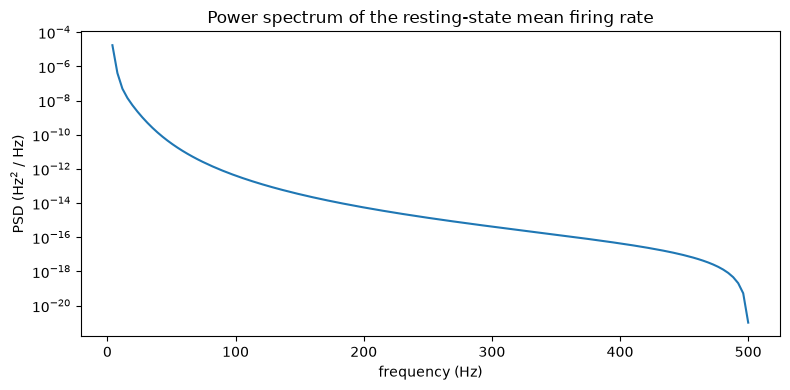

In [6]:
from scipy.signal import welch

fs = 1000.0  # TemporalAverage samples once per ms
freq, psd = welch(1e3 * r.mean(axis=1), fs=fs, nperseg=256)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(freq[1:], psd[1:])
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("PSD (Hz$^2$ / Hz)")
ax.set_title("Power spectrum of the resting-state mean firing rate")
plt.tight_layout()
plt.show()

## 5. Relaxation back to rest from a perturbed state

To show that the quiescent resting state is a *stable* attractor, we restart
the same connectome from a perturbed high-rate state (`r = 0.05 kHz`,
`v = -45 mV`) and watch the mean firing rate decay back towards the resting
level.

2026-09-23 13:58:53,935 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


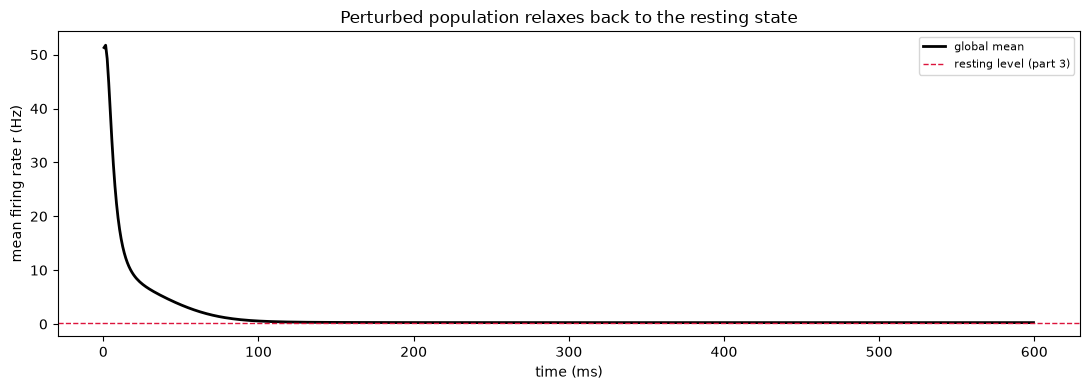

In [7]:
time_p, r_p = simulate(initial_rate=0.05, initial_v=-45.0, initial_u=5.0, sim_length=600.0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(time_p, 1e3 * r_p.mean(axis=1), color="k", lw=2, label="global mean")
ax.axhline(1e3 * r.mean(), color="crimson", ls="--", lw=1, label="resting level (part 3)")
ax.set_xlabel("time (ms)")
ax.set_ylabel("mean firing rate r (Hz)")
ax.set_title("Perturbed population relaxes back to the resting state")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

* The `GastSollaKennedy` mean-field model (Gast, Solla & Kennedy 2024, PNAS)
  was simulated on the full 76-region connectome with linear coupling and a
  deterministic Heun integrator.
* Starting at the quiescent fixed point with a small external current
  (`I = 30 pA`), the population remains in a **resting / quiescent regime**
  (near-zero mean firing rate, flat power spectrum).
* A perturbed initial condition relaxes back to that resting level, i.e. the
  quiescent state is a stable attractor of the network dynamics.

See the companion demo `reproduce_figure_Gast_2024_PNAS.ipynb` for the
bifurcation structure and firing-rate panels of the original paper.